# Support Vector Machine

The materials used in this tutorial are based on the applied exercises provided in the book <font color="orange">"An Introduction to Statistical Learning with Applications in Python"</font> (ISLP). We are trying to demonstrate how to use Python to train a SVM model on real-world datasets. Besides the exercises that we are going to cover in this tutorial, it is worth trying the other applied exercises given in the book by yourself.

The library for SVM is "svm" from sklearn.

## Task 1

We have seen that we can fit an SVM with a non-linear kernel in order to perform classification using a non-linear decision boundary. We will now see that we can also obtain a non-linear decision boundary by performing logistic regression using non-linear transformations of the features. 

### (a) 
Generate a data set with n = 500 and p = 2, such that the observations belong to two classes with a quadratic decision boundary between them. For instance, you can do this as follows: 

In [1]:
import numpy as np

In [2]:
np.random.seed(0)  # Setting a random seed for reproducibility
# Generate random data
x1 = np.random.rand(500) - 0.5
x2 = np.random.rand(500) - 0.5
# Calculate 'y' based on the condition
y = 1 * (x1**2 - x2**2 > 0)

### (b) 
Plot the observations, colored according to their class labels. Your plot should display X1 on the x-axis, and X2 on the y- axis. 

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,poly,
summarize)
from sklearn.linear_model import LogisticRegression

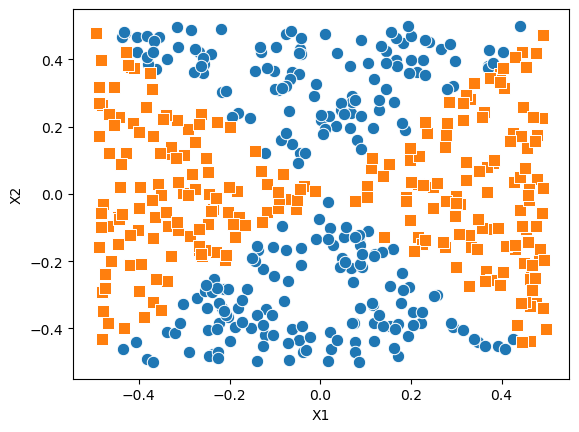

In [4]:
data = pd.DataFrame({'X1': x1, 'X2': x2, 'Y': y})
# Create the scatter plot using seaborn
markers = {0: 'o', 1: 's'}  # Define marker styles for each class (0 and 1)
for cls in markers:
    subset = data[data['Y'] == cls]
    sns.scatterplot(x='X1', y='X2', data=subset,  marker=markers[cls], s=80)

plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

### (c) 
Now fit a logistic regression model to the data using non-linear functions of $X_1$ and $X_2$ as predictors (e.g. $X_1^2, X_1 \times X_2, \log(X_2$), and so forth). 

In [19]:
data_poly = data.copy()
# Define polynomial features with degree 2
poly_X = PolynomialFeatures(degree=2, include_bias=False)
# Create polynomial features
poly_features = poly_X.fit_transform(data_poly[['X1', 'X2']])
poly_df = pd.DataFrame(poly_features, columns=['X1', 'X2','X1**2','X1*X2', 'X2**2'])
poly_df.head()

,X1,X2,X1**2,X1*X2,X2**2
0,0.048814,-0.189619,0.002383,-0.009256,0.035955
1,0.215189,-0.126965,0.046306,-0.027322,0.016120
2,0.102763,0.024970,0.010560,0.002566,0.000624
3,0.044883,0.250595,0.002015,0.011248,0.062798
4,-0.076345,-0.166493,0.005829,0.012711,0.027720


In [20]:
# Fit the logistic regression model
data_poly_y = data_poly['Y']
#data_poly_x = sm.add_constant(poly_features)
poly_logit_model = sm.GLM(data_poly_y, poly_df, family=sm.families.Binomial())
poly_logit_results = poly_logit_model.fit(max_iter=10)
# Print the summary of the model
print(poly_logit_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                  500
Model:                            GLM   Df Residuals:                      495
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Fri, 09 Aug 2024   Deviance:                   2.5831e-08
Time:                        00:05:22   Pearson chi2:                 1.29e-08
No. Iterations:                    36   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
X1         -1103.0639   3.57e+05     -0.003      0.9

C:\Users\quliz\anaconda3\lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
C:\Users\quliz\anaconda3\lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
C:\Users\quliz\anaconda3\lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +


Here again, none of the variables are statistically significants.

### (d) 
* Apply this model to the training data in order to obtain a predicted class label for each training observation. 
* Plot the observations, colored according to the predicted class labels. The decision boundary should be obviously non-linear. If it is not, then repeat (a)-(e) until you come up with an example in which the predicted class labels are obviously non-linear. 

C:\Users\quliz\anaconda3\lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


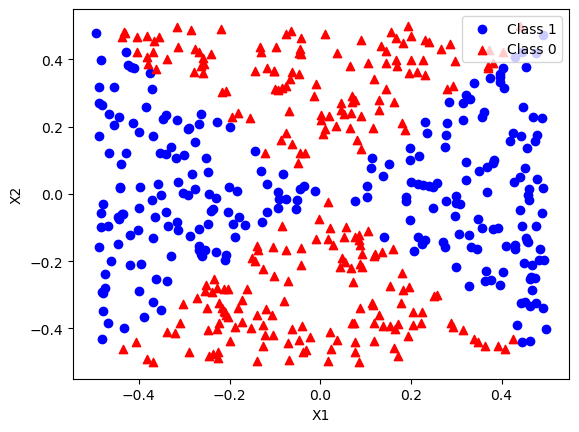

In [23]:
# Get predicted probabilities
probs = poly_logit_results.predict(poly_df)
#  Make binary predictions based on a threshold
threshold = 0.47
preds = np.where(probs > threshold, 1, 0)
# Create the scatter plot
plt.scatter(poly_df[preds == 1]['X1'], poly_df[preds == 1]['X2'], c='b', marker='o', label='Class 1')
plt.scatter(poly_df[preds == 0]['X1'], poly_df[preds == 0]['X2'], c='r', marker='^', label='Class 0')
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

The non-linear decision boundary is surprisingly very similar to the true decision boundary.

### (e) 
* Fit a support vector classifier to the data with X1 and X2 as predictors. 
* Obtain a class prediction for each training observation. 
* Plot the observations, colored according to the predicted class labels. 

In [24]:
data.Y

0      0
1      1
2      1
3      0
4      0
      ..
495    0
496    1
497    0
498    0
499    0
Name: Y, Length: 500, dtype: int32

In [25]:
data_svm = data.copy()
data_svm['Y'] = pd.Categorical(data_svm['Y'])
data_svm.head()

,X1,X2,Y
0,0.048814,-0.189619,0
1,0.215189,-0.126965,1
2,0.102763,0.024970,1
3,0.044883,0.250595,0
4,-0.076345,-0.166493,0


In [26]:
from sklearn import svm
# Assuming you have a DataFrame called 'data'
X = data_svm[['X1', 'X2']]
y = data_svm['Y']
# Create an SVM classifier with a linear kernel and specified cost
svm_classifier = svm.SVC(kernel='linear', C=0.01)
# Fit the SVM classifier to the data
svm_classifier.fit(X, y)
# Make predictions on the data
preds = svm_classifier.predict(X)
preds

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

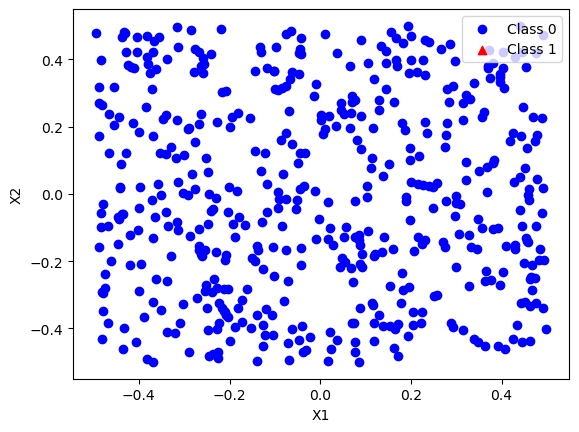

In [28]:
# Assuming you have a DataFrame called 'data'
data_svm['preds'] = preds  # Assuming 'preds' contains the predicted class labels
# Create scatter plot for class 0
plt.scatter(data_svm[data_svm['preds'] == 0]['X1'], data_svm[data_svm['preds'] == 0]['X2'], c='blue', marker='o', label='Class 0')

# Create scatter plot for class 1
plt.scatter(data_svm[data_svm['preds'] == 1]['X1'], data_svm[data_svm['preds'] == 1]['X2'], c='red', marker='^', label='Class 1')

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

This support vector classifier (even with low cost) classifies all points to a single class.

### (f) 
* Fit a SVM using a non-linear kernel to the data. 
* Obtain a class prediction for each training observation. 
* Plot the observations, colored according to the predicted class labels. 

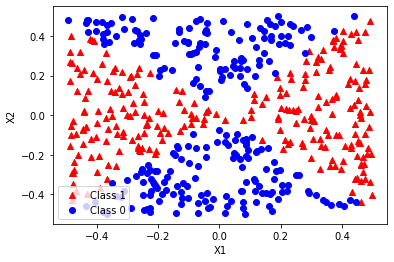

In [15]:
from sklearn.svm import SVC
# Create and train the SVM model
svm_nl = SVC(kernel='rbf', gamma=1, random_state=1)
svm_nl.fit(X, y)

# Predict class labels for all data points
preds = svm_nl.predict(X)

# Create a scatter plot for class 1 with red triangles ('^')
plt.scatter(data_svm[preds == 1]['X1'], data_svm[preds == 1]['X2'], c='red', marker='^', label='Class 1')

# Create a scatter plot for class 0 with blue circles ('o')
plt.scatter(data_svm[preds == 0]['X1'], data_svm[preds == 0]['X2'], c='blue', marker='o', label='Class 0')

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

Here again, the non-linear decision boundary is surprisingly very similar to the true decision boundary.

### (g) 
Comment on your results. 

We may conclude that SVM with non-linear kernel and logistic regression with interaction terms are equally very powerful for finding non-linear decision boundaries. Also, SVM with linear kernel and logistic regression without any interaction term are very bad when it comes to finding non-linear decision boundaries. However, one argument in favor of SVM is that it requires some manual tuning to find the right interaction terms when using logistic regression, although when using SVM we only need to tune gamma.

## Task 2 

This problem involves the OJ dataset. This dataset contains 1070 purchases where the customer either purchased Citrus Hill or Minute Maid  Orange Juice. A number of characteristics of the customer and product are recorded.

In [29]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
def evaluate_performance(model, x_eval, y_eval):
    y_pred = model.predict(x_eval)
    # Print classification report to evaluate the model
    # Calculate accuracy
    train_accuracy = accuracy_score(y_eval, y_pred)
    # Generate a classification report
    report = classification_report(y_eval, y_pred)
    # Calculate and display confusion matrix
    conf_matrix = confusion_matrix(y_eval, y_pred)
    print(f'1. Classification Report:\n{report}')
    print(f'2. Confusion Matrix:\n{conf_matrix}')
    print(f'3. Accuracy: {train_accuracy}')

### (a) 
Create a training set containing a random sample of 800 observations, and a test set containing the remaining observations. 

In [4]:
oj_df = pd.read_csv('OJ.csv')
# remove the first column which is 'Unnamed: 0'
oj_df = oj_df.iloc[:, 1:]
oj_df.head()

,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [18]:
# convert the Purchase and Store7 columns to factors: 0 and 1
oj_df_all = oj_df.copy()
oj_df_all['Purchase'] = oj_df_all['Purchase'].map({'CH': 0, 'MM': 1})
oj_df_all['Store7'] = oj_df_all['Store7'].map({'No': 0, 'Yes': 1})
oj_df_all.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,0,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,0,0.000000,0.000000,0.24,1
1,0,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,0,0.150754,0.000000,0.24,1
2,0,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,0,0.000000,0.091398,0.23,1
3,1,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,0,0.000000,0.000000,0.00,1
4,0,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,1,0.000000,0.000000,0.00,0


In [19]:
import random
nrow = len(oj_df_all)  # Replace OJ with your actual data
# Set the seed for reproducibility
random.seed(1)
# Generate a list of unique random indexes for the training data
train_index = random.sample(range(0, nrow), 800)  # 800 is the number of samples you want
oj_train_df = oj_df_all.loc[train_index]
oj_test_df = oj_df_all.drop(train_index)
print(oj_train_df.shape, oj_test_df.shape)

(800, 18) (270, 18)


In [20]:
# Assuming you have a DataFrame called OJ_train with 'Purchase' and other features
X_train = oj_train_df.drop('Purchase', axis=1)  # Features
y_train = oj_train_df['Purchase']  # Target variable
X_test = oj_test_df.drop('Purchase', axis=1)  # Features
y_test = oj_test_df['Purchase']  # Target variable

### (b) 
Fit a support vector classifier to the training data using cost=0.01, with Purchase as the response and the other variables as predictors. Use the summary() function to produce summary statistics, and describe the results obtained. 

In [21]:
from sklearn.svm import SVC
# Create and train the linear SVM model with C=0.01
svm_linear = SVC(kernel='linear', C=0.01)
svm_linear.fit(X_train, y_train)

SVC(C=0.01, kernel='linear')

In [22]:
# number of support vectors for each class
svm_linear.n_support_

array([305, 303], dtype=int32)

Support vector classifier creates 608 support vectors out of 800 training points. Out of these, 305 belong to level MM and remaining 303 belong to level CH.

### (c) 
What are the training and test error rates?

In [23]:
evaluate_performance(svm_linear, X_train, y_train)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       493
           1       0.78      0.59      0.67       307

    accuracy                           0.78       800
   macro avg       0.78      0.74      0.75       800
weighted avg       0.78      0.78      0.77       800

2. Confusion Matrix:
[[441  52]
 [126 181]]
3. Accuracy: 0.7775


In [24]:
evaluate_performance(svm_linear, X_test, y_test)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.95      0.84       160
           1       0.88      0.55      0.68       110

    accuracy                           0.79       270
   macro avg       0.82      0.75      0.76       270
weighted avg       0.81      0.79      0.78       270

2. Confusion Matrix:
[[152   8]
 [ 49  61]]
3. Accuracy: 0.7888888888888889


### (d) 
Use the GridSearchCV() or RandomizedSearchCV() function to select an optimal cost. Consider values in the range 0.01 to 10. 

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid with a range of 'C' values
param_grid = {'C': [10**(-2), 10**(-1.75), 10**(-1.5), 10**(-1.25), 1.0, 10**(0.25), 10**(0.5), 10**(0.75)]}

# Create an SVM classifier with a linear kernel
svm_linear_cv = SVC(kernel='linear')

# Create a GridSearchCV object with cross-validation
grid_search = GridSearchCV(estimator=svm_linear_cv, param_grid=param_grid, cv=10)

# Fit the grid search to your training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params_cv = grid_search.best_params_
print("Best Hyperparameters:", best_params_cv)
# Get the best estimator (model) with the tuned hyperparameters
best_svm_linear_cv = grid_search.best_estimator_
print("Best Estimator:", best_svm_linear_cv)
print("Best Score:", grid_search.best_score_)

Best Hyperparameters: {'C': 1.0}
Best Estimator: SVC(kernel='linear')
Best Score: 0.8324999999999999


In [26]:
best_c = grid_search.best_params_['C']
best_c

1.0

We may see that the optimal cost is 1.0

### (e) 
Compute the training and test error rates using this new value for cost.

In [27]:
# Create an SVM classifier with the best 'C' value
svm_linear_best_c = svm.SVC(kernel='linear', C=best_c)
# Train the SVM model on the training data
svm_linear_best_c.fit(X_train, y_train)
# Make predictions on the training data

SVC(kernel='linear')

In [28]:
evaluate_performance(svm_linear_best_c, X_train, y_train)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       493
           1       0.80      0.78      0.79       307

    accuracy                           0.84       800
   macro avg       0.83      0.83      0.83       800
weighted avg       0.84      0.84      0.84       800

2. Confusion Matrix:
[[433  60]
 [ 68 239]]
3. Accuracy: 0.84


In [29]:
# Make predictions on the test data
evaluate_performance(svm_linear_best_c, X_test, y_test)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       160
           1       0.83      0.71      0.76       110

    accuracy                           0.82       270
   macro avg       0.82      0.80      0.81       270
weighted avg       0.82      0.82      0.82       270

2. Confusion Matrix:
[[144  16]
 [ 32  78]]
3. Accuracy: 0.8222222222222222


### (f) 
Repeat parts (b) through (e) using a support vector machine with a radial kernel. Use the default value for “gamma”.

In [30]:
# Create an SVM classifier with a radial kernel (RBF): default gamma = 'scale' if auto is used, gamma = 1/n_features
svm_radial_gamma = svm.SVC(kernel='rbf', C=best_c, gamma='auto')
# Train the SVM model on the training data
svm_radial_gamma.fit(X_train, y_train)

SVC(gamma='auto')

In [31]:
# number of support vectors for each class
svm_radial_gamma.n_support_

array([280, 265], dtype=int32)

In [32]:
evaluate_performance(svm_radial_gamma, X_train, y_train)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       493
           1       0.78      0.66      0.71       307

    accuracy                           0.80       800
   macro avg       0.79      0.77      0.78       800
weighted avg       0.79      0.80      0.79       800

2. Confusion Matrix:
[[435  58]
 [105 202]]
3. Accuracy: 0.79625


In [33]:
# Make predictions on the test data
evaluate_performance(svm_radial_gamma, X_test, y_test)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.86      0.78       160
           1       0.71      0.51      0.59       110

    accuracy                           0.71       270
   macro avg       0.71      0.68      0.69       270
weighted avg       0.71      0.71      0.70       270

2. Confusion Matrix:
[[137  23]
 [ 54  56]]
3. Accuracy: 0.7148148148148148


Radial kernel with default gamma creates 545 support vectors, out of which, 280 belong to level CH and remaining 265 belong to level MM. The classifier has a training error of 21% and a test error of 28% which is a not improving comparing with linear kernel. That's very possibly due to the choose of auto selection of gamma. Let's try the optimal gamma now.

In [34]:
# Define a range of cost values to tune
cost_values = 10.0 ** np.arange(-2, 2, 0.25)
# Create a parameter grid for the hyperparameter search
param_grid = {'C': cost_values}

# Initialize the SVM classifier
svm_classifier = SVC(kernel='rbf', gamma='auto')

# Perform hyperparameter tuning using GridSearchCV
grid_search = GridSearchCV(svm_classifier, param_grid, cv=10)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from the search
best_params = grid_search.best_params_
best_cost = best_params['C']
print("Best Cost:", best_cost)

Best Cost: 5.623413251903491


In [35]:
# Train an SVM classifier with the best hyperparameters
best_svm_radial = SVC(C=best_cost, kernel='rbf', gamma='auto')
best_svm_radial.fit(X_train, y_train)
# Evaluate the model on the test set
accuracy = best_svm_radial.score(X_train, y_train)
print(f"Best SVM model accuracy on the test set: {accuracy}")

Best SVM model accuracy on the test set: 0.8575


In [36]:
evaluate_performance(best_svm_radial, X_train, y_train)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       493
           1       0.86      0.76      0.80       307

    accuracy                           0.86       800
   macro avg       0.86      0.84      0.85       800
weighted avg       0.86      0.86      0.86       800

2. Confusion Matrix:
[[454  39]
 [ 75 232]]
3. Accuracy: 0.8575


In [37]:
# Make predictions on the test data
evaluate_performance(best_svm_radial, X_test, y_test)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.86      0.80       160
           1       0.74      0.57      0.65       110

    accuracy                           0.74       270
   macro avg       0.74      0.72      0.72       270
weighted avg       0.74      0.74      0.74       270

2. Confusion Matrix:
[[138  22]
 [ 47  63]]
3. Accuracy: 0.7444444444444445


### (g) 
Repeat parts (b) through (e) using a support vector machine with a polynomial kernel. Set degree=2. 

best cost is 0.1 in (b) and 1.0 in (e)  

In [38]:
# Create an SVM classifier with a polynomial kernel
svm_poly = svm.SVC(kernel='poly', degree=2, C=0.01, gamma='auto')
# Train the SVM model on the training data
svm_poly.fit(X_train, y_train)

SVC(C=0.01, degree=2, gamma='auto', kernel='poly')

In [39]:
# print number of support vectors for each class
svm_poly.n_support_

array([168, 165], dtype=int32)

In [40]:
# Make predictions on the training data
evaluate_performance(svm_poly, X_train, y_train)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       493
           1       0.80      0.77      0.78       307

    accuracy                           0.84       800
   macro avg       0.83      0.83      0.83       800
weighted avg       0.84      0.84      0.84       800

2. Confusion Matrix:
[[433  60]
 [ 70 237]]
3. Accuracy: 0.8375


In [41]:
# Make predictions on the test data
evaluate_performance(svm_poly, X_test, y_test)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       160
           1       0.84      0.75      0.79       110

    accuracy                           0.84       270
   macro avg       0.84      0.82      0.83       270
weighted avg       0.84      0.84      0.84       270

2. Confusion Matrix:
[[144  16]
 [ 28  82]]
3. Accuracy: 0.837037037037037


Polynomial kernel with default gamma creates 333 support vectors, out of which, 224 belong to level CH and remaining 230 belong to level MM. The classifier has a training error of 16.3% and a test error of 16.3% which is big improvement over linear kernel. We now use cross validation to find optimal cost.

In [42]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
# Define a range of cost values to tune
cost_values = 10.0 ** np.arange(-2, 2, 0.25)
# Create a parameter grid to search over
param_grid = {
    'svc__kernel': ['poly'],
    'svc__degree': [2],
    'svc__gamma': ['auto'],  # List of gamma values to search
    'svc__C': cost_values,  # List of C values to search
}
# Create a parameter grid for the hyperparameter search
# Initialize the SVM classifier
clf = make_pipeline(StandardScaler(), SVC(kernel='poly',degree=2, gamma='auto'))
# Perform hyperparameter tuning using GridSearchCV
grid_search = GridSearchCV(clf, param_grid, cv=10)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from the search
best_params = grid_search.best_params_
best_cost = best_params['svc__C']
print("Best Cost:", best_cost)

Best Cost: 56.23413251903491


In [43]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
clf = make_pipeline(StandardScaler(), SVC(kernel='poly',degree=2, C=best_cost, gamma='auto'))
clf.fit(X_train, y_train)
accuracy = clf.score(X_train, y_train)
print(f"Best SVM model accuracy on the Train set: {accuracy}")

Best SVM model accuracy on the Train set: 0.81125


In [44]:
# show the number of support vectors for each class
clf.named_steps['svc'].n_support_

array([213, 205], dtype=int32)

In [45]:
# Make predictions on the training data
evaluate_performance(clf, X_train, y_train)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       493
           1       0.83      0.64      0.72       307

    accuracy                           0.81       800
   macro avg       0.82      0.78      0.79       800
weighted avg       0.81      0.81      0.81       800

2. Confusion Matrix:
[[452  41]
 [110 197]]
3. Accuracy: 0.81125


In [46]:
# Make predictions on the test data
evaluate_performance(clf, X_test, y_test)

1. Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       160
           1       0.83      0.62      0.71       110

    accuracy                           0.79       270
   macro avg       0.80      0.77      0.77       270
weighted avg       0.80      0.79      0.79       270

2. Confusion Matrix:
[[146  14]
 [ 42  68]]
3. Accuracy: 0.7925925925925926


Tuning reduce train and test error rates.

Overall, which approach seems to give the best results on this data ?

Overall, radial basis kernel seems to be producing minimum misclassification error on both train data. And polynomial kernel seems to be producing minimum misclassification error on test data.

Based on above results from different models, list all the training and testing accuracy as follows:

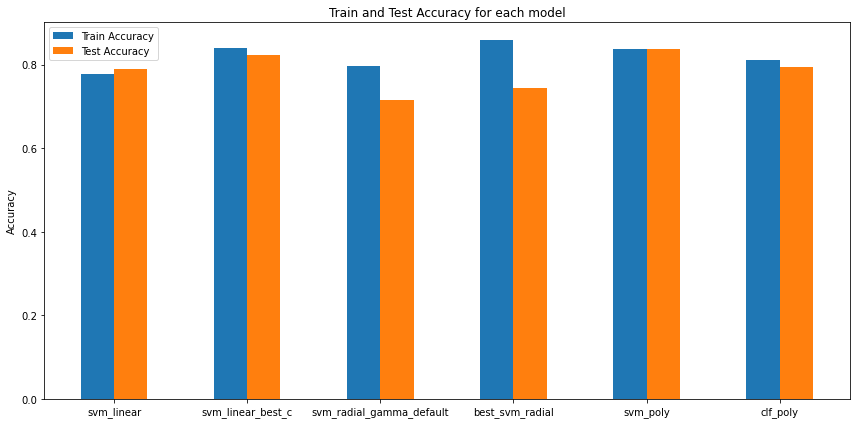

In [53]:
# models = svm_linear, svm_linear_best_c, svm_radial_gamma_default,
# best_svm_radial, svm_poly, clf_poly
# training accuracy: [0.778, 0.84, 0.796, 0.858, 0.838, 0.811]
# testing acc: [0.789, 0.822, 0.715, 0.744, 0.837, 0.793]
models = ['svm_linear', 'svm_linear_best_c', 'svm_radial_gamma_default', 'best_svm_radial', 'svm_poly', 'clf_poly']
train_acc = [0.778, 0.84, 0.796, 0.858, 0.838, 0.811]
test_acc = [0.789, 0.822, 0.715, 0.744, 0.837, 0.793]
# display the above train test accuracy for each model in bar plot
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots()
# set the figure size
fig.set_size_inches(12, 6)
rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
rects2 = ax.bar(x + width/2, test_acc, width, label='Test Accuracy')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy')
ax.set_title('Train and Test Accuracy for each model')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
fig.tight_layout()
plt.show()
